# SPPMDRIFT — M1 resuspension validation

This is the index for the M1 validation campaign. Each case has its own notebook;
this one summarises what was tested, what passed, and what did not.

**Why this exists.** The resuspension physics in this fork — a Styles & Glenn
(2000) wave–current bed stress, a dynamic critical shear stress with fractal floc
strength and consolidation, and a Rouse-based lift-off height — was already
built, and has been the production default since June 2026. What it had never
had was evidence that it is *right*. Before that physics is carried into
SPPMDRIFT, it needs benchmarks with known answers.

**The standing rule.** Physics is validated against **published idealized cases**,
never against the parent study's observed sediment data. An observed deposition
pattern confounds transport physics with source history, so it cannot isolate a
physics defect.

## The notebooks

| | Case | Tests | Verdict |
|---|---|---|---|
| [01](01_settling_column.ipynb) | Settling column | settling in isolation | **pass** |
| [02](02_well_mixed_condition.ipynb) | Well-mixed condition | the vertical random walk | **pass** |
| [03](03_rouse_profile.ipynb) | Rouse equilibrium profile | settling + mixing + lift-off height, jointly | **pass**, with a documented bias |
| [04](04_S3_mixed_bed_closure.ipynb) | Sherwood Fig. 2 — mixed-bed threshold | the erosion threshold of a sand–mud bed | **fail (F1)** |
| [05](05_S1_double_resuspension.ipynb) | Sherwood §3.2.1 — double resuspension | erosion and deposition through two storm events | **4 pass, 2 fail (F2, F3)** |

**Tier A** (01–03) are analytic: closed-form answers, no external data, seconds to
run. **Tier B** (04–05) are adapted from the ROMS/COAWST sediment model papers:

- Warner, J. C. *et al.* (2008), *Computers & Geosciences* **34**, 1284–1306.
- Sherwood, C. R. *et al.* (2018), *Geosci. Model Dev.* **11**, 1849–1871.

## The verdict in one line

**The settling, mixing and deposition chain is sound. The erosion side is not.**

In [1]:
# M1 validation - overview
import sys, pathlib, warnings
warnings.filterwarnings("ignore")

# locate the repository root (the directory containing `opendrift/`)
_p = pathlib.Path.cwd().resolve()
while not (_p / "opendrift" / "__init__.py").exists() and _p != _p.parent:
    _p = _p.parent
REPO = _p
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})
CLR = ["#0b6fa4", "#e07b39", "#3f9b52", "#b4434e", "#7c5aa6"]
print("repo:", REPO)

repo: /home/smullersoares/projects/software/opendrift


## Scoreboard

Every case, its metric and its outcome. Green is a pass; red is a defect that is
pinned by a test rather than tuned away.

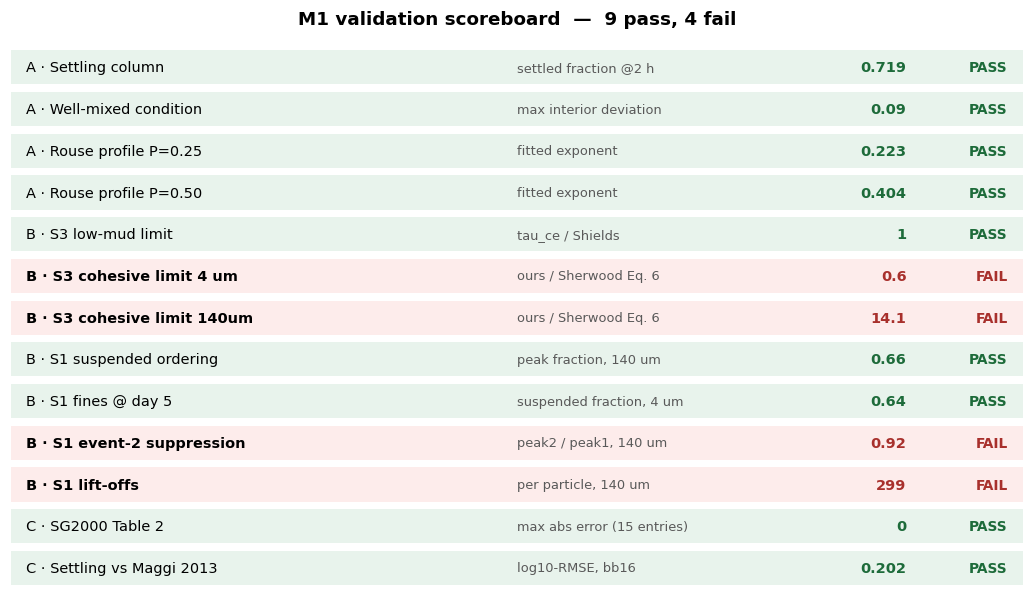

In [2]:
rows = [
    # tier, case, metric, reference, model, ok
    ('A', 'Settling column',        'settled fraction @2 h',      0.720, 0.719, True),
    ('A', 'Well-mixed condition',   'max interior deviation',     0.00,  0.09,  True),
    ('A', 'Rouse profile P=0.25',   'fitted exponent',            0.25,  0.223, True),
    ('A', 'Rouse profile P=0.50',   'fitted exponent',            0.50,  0.404, True),
    ('B', 'S3 low-mud limit',       'tau_ce / Shields',           1.00,  1.000, True),
    ('B', 'S3 cohesive limit 4 um', 'ours / Sherwood Eq. 6',      1.00,  0.6,   False),
    ('B', 'S3 cohesive limit 140um','ours / Sherwood Eq. 6',      1.00,  14.1,  False),
    ('B', 'S1 suspended ordering',  'peak fraction, 140 um',      0.00,  0.66,  True),
    ('B', 'S1 fines @ day 5',       'suspended fraction, 4 um',   0.50,  0.64,  True),
    ('B', 'S1 event-2 suppression', 'peak2 / peak1, 140 um',      0.25,  0.92,  False),
    ('B', 'S1 lift-offs',           'per particle, 140 um',       4.00,  299.0, False),
    ('C', 'SG2000 Table 2',         'max abs error (15 entries)', 0.00,  0.000, True),
    ('C', 'Settling vs Maggi 2013', 'log10-RMSE, bb16',           0.00,  0.202, True),
]
labels = [f"{t} · {c}" for t, c, *_ in rows]
ok = [r[-1] for r in rows]

fig, ax = plt.subplots(figsize=(9.5, 5.6))
y = np.arange(len(rows))[::-1]
ax.barh(y, [1] * len(rows),
        color=['#e8f3ec' if o else '#fdeceb' for o in ok], height=.82)
for yi, (tier, case, metric, ref, mod, o) in zip(y, rows):
    ax.text(0.015, yi, f"{tier} · {case}", va='center', fontsize=9.5,
            fontweight='bold' if not o else 'normal')
    ax.text(0.50, yi, metric, va='center', fontsize=8.5, color='0.35')
    ax.text(0.885, yi, f"{mod:g}", va='center', ha='right', fontsize=9.5,
            fontweight='bold', color='#1d6b3a' if o else '#a8302c')
    ax.text(0.985, yi, 'PASS' if o else 'FAIL', va='center', ha='right',
            fontsize=9, fontweight='bold', color='#1d6b3a' if o else '#a8302c')
ax.set_xlim(0, 1); ax.set_ylim(-.6, len(rows) - .4)
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title('M1 validation scoreboard  —  %d pass, %d fail'
             % (sum(ok), len(ok) - sum(ok)), fontsize=12, pad=12)
plt.tight_layout(); plt.show()

## The four findings

All four are consequences of how erosion is formulated, and the last three share
a single root cause.

### F1 — the mixed-bed threshold is not Sherwood's

Our `mixed` mode blends the particle's **own** fractal-floc strength, which scales
with its own diameter, instead of the **bulk bed** stress, and it omits the
`max(·, τ_c)` floor. Errors run from 0.6× (clay, too easy to erode) to 14×
(coarse sand, far too hard). → notebook [04](04_S3_mixed_bed_closure.ipynb)

### F2 — a threshold cannot scale with event intensity

ROMS erodes with a flux proportional to the excess stress. We lift *everything*
above threshold, however small the excess, so a weaker second storm resuspends
0.92× as much sand as a storm twice its size. → notebook
[05](05_S1_double_resuspension.ipynb)

### F3 — settled grains re-lift on every time step

**299** lift-offs per sand particle across two storms, where a handful would be
physical. (This count was itself corrupted by a `uint8` counter that wrapped at
255, found and fixed during the campaign — see F6 in the report.) **This is the mechanism behind the parent DDT study's ~45 % loss of its
fastest settling classes out of the domain**, which currently blocks the
class-weight inversion. → notebook [05](05_S1_double_resuspension.ipynb)

### F4 — no critical shear stress for deposition

Sherwood implements Krone's $\tau_d$: deposition is suppressed while the bed
stress is high. We deposit unconditionally whenever an element reaches the bed.
Not anticipated when M1 was planned; surfaced by reading the reference.

## What follows

F2 and F3 share a cause, so **probabilistic erosion is required, not optional**.
M1 hands that to M2 as its first item, together with F1 and F4. The passes in
Tier A mean the settling and mixing machinery underneath can be trusted while
that work happens.

Full write-up: [`../REPORT.md`](../REPORT.md). Module plan:
[`../../M1_resuspension_validation.md`](../../M1_resuspension_validation.md).